CELL 1: IMPORT THƯ VIỆN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("Import thành công")

Import thành công


CELL 2: LOAD DATA

In [2]:
print("Load cleaned data from step 2")

df = pd.read_csv(r'D:\Delivery_Time_Prediction_project\data\processed\step2_cleaned_data.csv')

print(f" Data loaded: {df.shape}")
print(f"   Row: {df.shape[0]}")
print(f"   Columns: {df.shape[1]}")

Load cleaned data from step 2
 Data loaded: (97248, 26)
   Row: 97248
   Columns: 26


CELL 3: BASIC EXPLORATION

In [3]:
print("\nBASIC EXPLORATION")

print("\n--- Shape & info ---")
print(f"Shape: {df.shape}")

print("\n---- First 5 rows ----")
print(df.head())

print("\n ---Data Types----")
print(df.dtypes)

print("\n --- Info---")
print(df.info())

print("\n ---- Missing Values----")
missing = df.isnull().sum()

if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values")

print("\n --- Duplicate----")
dup_count = df.duplicated().sum()
print(f"\n Duplicate rows: {dup_count}")


BASIC EXPLORATION

--- Shape & info ---
Shape: (97248, 26)

---- First 5 rows ----
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:

CELL 4: PHÂN TÍCH DELIVERY_TIME

In [4]:
print("\n\n TARGET VARIABLE: delivery_time")

print("\n--- Statistics ---")
print(f"Count:    {df['delivery_time'].count():,}")
print(f"Mean:     {df['delivery_time'].mean():.4f} days")
print(f"Median:   {df['delivery_time'].median():.4f} days")
print(f"Std:      {df['delivery_time'].std():.4f} days")
print(f"Min:      {df['delivery_time'].min():.4f} days")
print(f"Max:      {df['delivery_time'].max():.4f} days")
print(f"25%:      {df['delivery_time'].quantile(0.25):.4f} days")
print(f"50%:      {df['delivery_time'].quantile(0.5):.4f} days")
print(f"75%       {df['delivery_time'].quantile(0.75):.4f} days")





 TARGET VARIABLE: delivery_time

--- Statistics ---
Count:    97,248
Mean:     12.0821 days
Median:   9.8114 days
Std:      9.4770 days
Min:      0.0077 days
Max:      208.5010 days
25%:      6.2860 days
50%:      9.8114 days
75%       15.0846 days


CELL 5: VẼ BIỂU ĐỒ 

VISUALIZATION - TARGET VARIABLE


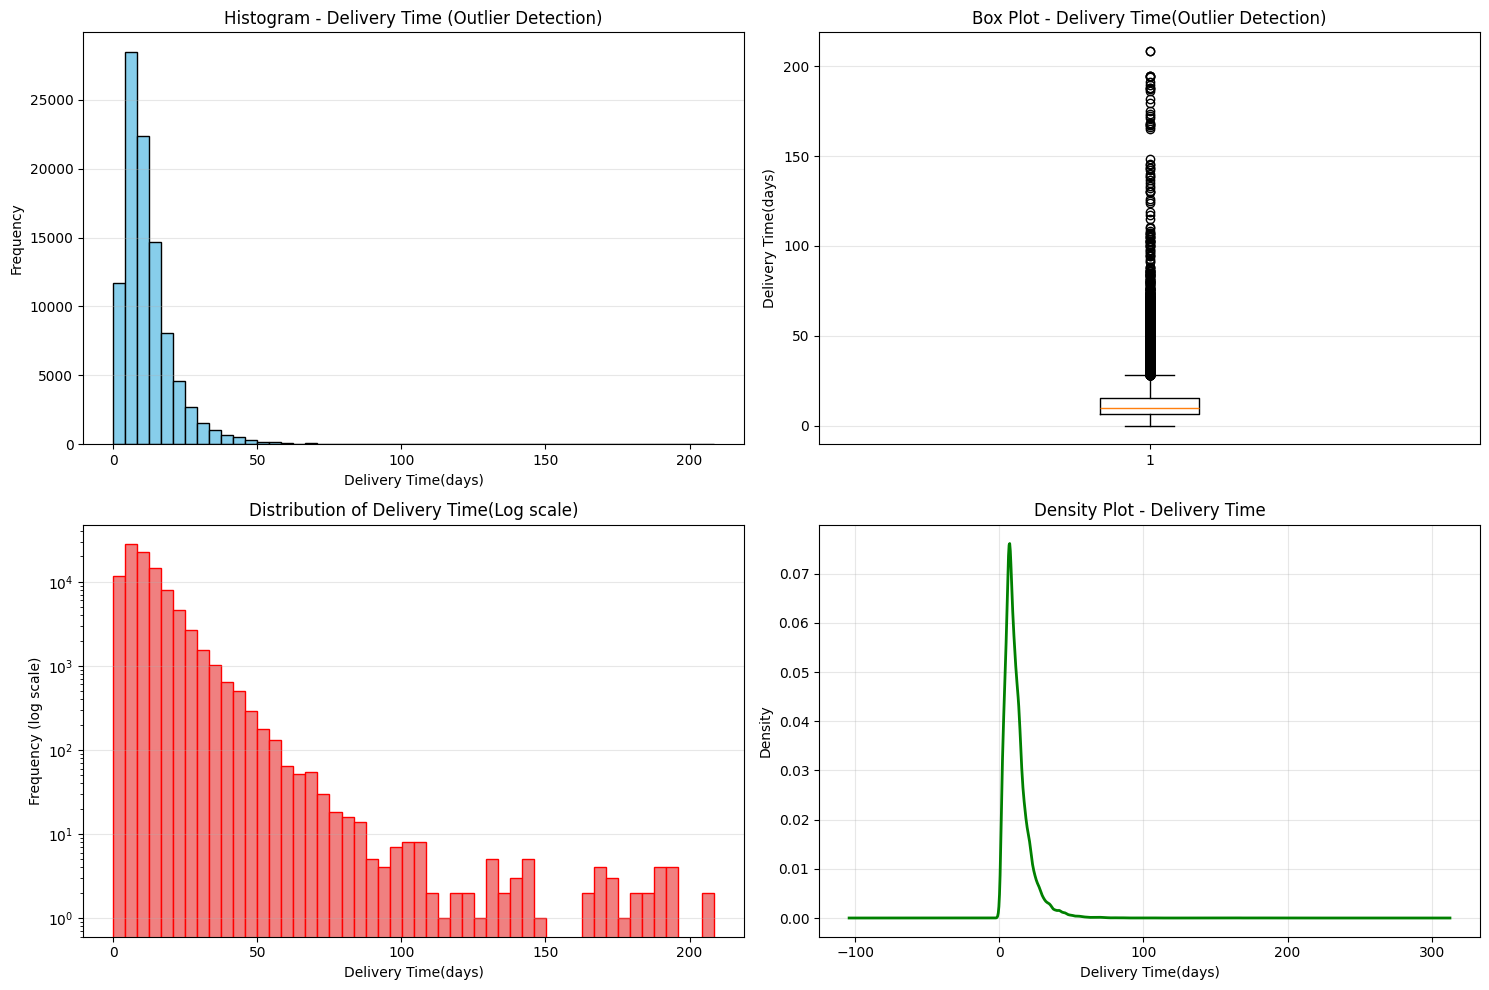

In [5]:
print("VISUALIZATION - TARGET VARIABLE")

fig, axes = plt.subplots(2,2, figsize=(15,10))

#Histogram
axes[0, 0].hist(df['delivery_time'], bins=50, edgecolor='black', color='skyblue')
axes[0, 0].set_xlabel('Delivery Time(days)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Histogram - Delivery Time (Outlier Detection)')
axes[0, 0].grid(axis='y', alpha=0.3)

#Boxplot
axes[0, 1].boxplot(df['delivery_time'], vert=True)
axes[0, 1].set_ylabel('Delivery Time(days)')
axes[0, 1].set_title('Box Plot - Delivery Time(Outlier Detection)')
axes[0, 1].grid(axis='y', alpha=0.3)

#Histogram(log scale)
axes[1, 0].hist(df['delivery_time'], bins=50, edgecolor='red', color='lightcoral')
axes[1, 0].set_xlabel('Delivery Time(days)')
axes[1, 0].set_ylabel('Frequency (log scale)')
axes[1, 0].set_title('Distribution of Delivery Time(Log scale)')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(axis='y', alpha=0.3)

#KDE Plot
df['delivery_time'].plot(kind='density', ax=axes[1, 1], color='green',linewidth=2)
axes[1, 1].set_xlabel('Delivery Time(days)')
axes[1, 1].set_title('Density Plot - Delivery Time')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

CELL 5: OUTLIER DETECTION

In [7]:
print("\n\n OUTLIER DETECTION - Delivery_time")

Q1 = df['delivery_time'].quantile(0.25)
Q3 = df['delivery_time'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

print("\n--- IQR Method ---")
print(f"Q1: {Q1:.4f}")
print(f"Q3: {Q3:.4f}")
print(f"IQR: {IQR:.4f}")
print(f"Lower bound: {lower_bound:.4f}")
print(f"Upper bound: {upper_bound:.4f}")

outliers = df[(df['delivery_time'] < lower_bound)|(df['delivery_time'] > upper_bound)]
print(f"\nOutliers found: {len(outliers):,} ({100*len(outliers)/len(df):.4f}%)")

if len(outliers) > 0:
    print("\nOutlier value: ")
    print(f"Min: {outliers['delivery_time'].min():.2f}")
    print(f"Max: {outliers['delivery_time'].max():.2f}")
    print(f"\nOutlier distribution")
    print(outliers['delivery_time'].describe())



 OUTLIER DETECTION - Delivery_time

--- IQR Method ---
Q1: 6.2860
Q3: 15.0846
IQR: 8.7986
Lower bound: -6.9118
Upper bound: 28.2824

Outliers found: 5,094 (5.2382%)

Outlier value: 
Min: 28.28
Max: 208.50

Outlier distribution
count    5094.000000
mean       39.782410
std        16.073611
min        28.283796
25%        31.130961
50%        35.246001
75%        42.766105
max       208.500972
Name: delivery_time, dtype: float64
